# UCI HAR Dataset 기반 Mamba-like 분류

이 모델은 공식 Mamba를 완전히 구현한 것이 아니라 Mamba의 핵심 구조를 공부하기 위한 단순화 버전이다.

## 결과 분석

Model 1: Mamba-like only

- Test accuracy: 90.80%

Model 2: Conv1D + Mamba-like

- Test accuracy: 94.98%

Model1은 Mamba-like block의 구조만을 사용하여 90.80%의 정확도를 기록하였다.

그리고 Model2는 Conv1D를 앞단에 추가하여 Mamba-like block를 통과하였을 때 94.98%의 정확도를 기록하며 더 높은 성능을 보였다.

따라서 HAR 데이터는 짧은 구간에서 local pattern을 먼저 추출하는 것이 중요하며, 이후 Mamba-like와 같이 시간축으로 누적하여 전체 흐름을 학습하는 방식이 효과적임을 보여준다.

In [1]:
# 라이브러리 import
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input,
    Dense,
    Dropout,
    Concatenate,
    GaussianNoise,
    LayerNormalization,
    Conv1D,
    BatchNormalization,
    ReLU,
    GlobalAveragePooling1D,
    GlobalMaxPooling1D
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

from sklearn.metrics import classification_report, confusion_matrix


In [2]:
# 구글 드라이브 연결
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# 경로 정의
DATASET_PATH = "/content/drive/MyDrive/UCI HAR Dataset/"

TRAIN = "train/"
TEST = "test/"

# 입력으로 사용할 9개의 센서 채널
INPUT_SIGNAL_TYPES = [
    "body_acc_x_",
    "body_acc_y_",
    "body_acc_z_",
    "body_gyro_x_",
    "body_gyro_y_",
    "body_gyro_z_",
    "total_acc_x_",
    "total_acc_y_",
    "total_acc_z_"
]

# 혼동 행렬이나 결과 해석 시 읽기 쉬운 동작 이름 정의
LABELS = [
    "WALKING",
    "WALKING_UPSTAIRS",
    "WALKING_DOWNSTAIRS",
    "SITTING",
    "STANDING",
    "LAYING"
]

In [4]:
# X 데이터 로드 함수
def load_X(X_signals_paths):
    X_signals = [] # 전체 센서 채널(9개)을 담을 리스트

    # 센서 파일(9개)을 하나씩 순회
    for signal_type_path in X_signals_paths:
        signal_data = [] # 현재 센서 채널의 모든 샘플 데이터를 담을 리스트

        with open(signal_type_path, 'r') as file:
            for row in file:

                # 문자열 전처리
                # 1. 공백 정리
                # 2. 양끝 공백 제거
                # 3. 공백 기준으로 split -> 문자열 숫자 리스트로 변환
                row = row.replace('  ', ' ').strip().split(' ')

                # 문자열 → float32 숫자로 변환
                row = [np.float32(x) for x in row]

                # 하나의 sample을 리스트에 추가
                signal_data.append(row)

        # 현재 센서 채널 전체 데이터를 추가
        X_signals.append(signal_data)

    # 리스트 -> numpy 배열로 변환
    X_signals = np.array(X_signals)

    # CNN 입력 형태로 변환
    # (channels, samples, time) -> (samples, time, channels)
    # 원래 shape: (9, samples, 128)
    # 변환 후 shape: (samples, 128, 9)
    return np.transpose(X_signals, (1, 2, 0))

In [5]:
# y 데이터 로드 함수
def load_y(y_path):
    y = [] # 전체 샘플의 정답 라벨을 담을 리스트
    with open(y_path, 'r') as file:
        for row in file:

            # 문자열 형태의 숫자를 읽어서 공백 제거 후 정수로 변환
            y.append(int(row.strip()))

    # 리스트 -> numpy 배열로 변환
    y = np.array(y, dtype=np.int32)

    # 원래 라벨이 1~6이라서 딥러닝에서 사용하 0~5로 변경
    return y - 1

In [6]:
# 데이터 로드

# train용 9개 센서 파일 경로를 리스트로 생성
X_train_signals_paths = [
    DATASET_PATH + TRAIN + "Inertial Signals/" + signal + "train.txt"
    for signal in INPUT_SIGNAL_TYPES
]

# test용 9개 센서 파일 경로를 리스트로 생성
X_test_signals_paths = [
    DATASET_PATH + TEST + "Inertial Signals/" + signal + "test.txt"
    for signal in INPUT_SIGNAL_TYPES
]

# train 입력 데이터 로드
X_train = load_X(X_train_signals_paths)
# test 입력 데이터 로드
X_test = load_X(X_test_signals_paths)

# train 정답 라벨 로드
y_train = load_y(DATASET_PATH + TRAIN + "y_train.txt")
# test 정답 라벨 로드
y_test = load_y(DATASET_PATH + TEST + "y_test.txt")

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (7352, 128, 9)
X_test shape: (2947, 128, 9)
y_train shape: (7352,)
y_test shape: (2947,)


In [7]:
# 데이터 표준화
# 채널마다 값의 범위가 다를 수 있어서
# 평균 0, 표준편차 1 근처로 맞춰주면 학습이 더 안정적임

mean = X_train.mean(axis=(0, 1), keepdims=True)
std = X_train.std(axis=(0, 1), keepdims=True) + 1e-8

X_train = (X_train - mean) / std
X_test = (X_test - mean) / std

print("표준화 완료")

표준화 완료


In [8]:
# One-hot 인코딩
# softmax 출력과 label smoothing을 쓰기 위해 one-hot으로 변환
y_train_onehot = tf.keras.utils.to_categorical(y_train, num_classes=6)
y_test_onehot = tf.keras.utils.to_categorical(y_test, num_classes=6)

print("y_train_onehot shape:", y_train_onehot.shape)
print("y_test_onehot shape:", y_test_onehot.shape)

y_train_onehot shape: (7352, 6)
y_test_onehot shape: (2947, 6)


#Model1: Mamba-like Only

Model1은 입력 시계열 데이터를 Mamba-like block에 바로 통과시켜, 시간에 따라 변화하는 전체 흐름을 학습하는 구조이다.

## Mamba-like Block

### 핵심 흐름
1. **Input projection**: 입력 feature를 더 넓은 hidden dimension으로 확장
2. **Gate branch**: 어떤 정보를 통과시킬지 결정
3. **SSM-like recurrence**: 시간축을 따라 이전 상태를 누적하면서 sequence 정보를 반영
4. **Output projection**: 다시 원래 feature dimension으로 복원
5. **Residual connection**: 입력 정보를 보존하면서 변화량만 학습

In [9]:
# Mamba-like Block 정의
# Mamba의 핵심 흐름인 projection + gate + state update + residual을 학습하기 위한 구조

@tf.keras.utils.register_keras_serializable()
class MambaLikeBlock(tf.keras.layers.Layer):
    def __init__(self, d_model, expand=2, dropout=0.1, **kwargs):
        super().__init__(**kwargs)
        self.d_model = d_model
        self.expand = expand
        self.dropout_rate = dropout
        self.d_inner = d_model * expand

        # Pre-Norm
        self.norm = LayerNormalization()

        # 입력을 feature branch와 gate branch로 나누기 위한 projection
        self.in_proj = Dense(self.d_inner * 2)

        # SSM-like update에 사용할 값 생성
        self.delta_proj = Dense(self.d_inner, activation="softplus")
        self.B_proj = Dense(self.d_inner, activation="tanh")
        self.C_proj = Dense(self.d_inner, activation="sigmoid")

        # 출력 차원 복원
        self.out_proj = Dense(d_model)
        self.dropout = Dropout(self.dropout_rate)

    def simple_selective_scan(self, u, delta, B, C):
        # u: 현재 입력 정보
        # delta: 현재 시점에서 상태를 얼마나 반영할지 결정하는 값
        # B: 입력을 상태에 넣는 강도
        # C: 상태를 출력으로 읽는 강도
        # 단순화된 상태 누적:
        # h_t = Σ(delta_i * B_i * u_i), i <= t
        # y_t = C_t * tanh(h_t)

        delta = tf.clip_by_value(delta, 0.0, 1.0)

        state_input = delta * B * u
        state = tf.cumsum(state_input, axis=1)
        state = tf.nn.tanh(state)

        y = C * state
        return y

    def call(self, x, training=False):
        residual = x

        # 1) 정규화
        x = self.norm(x)

        # 2) feature branch와 gate branch 분리
        x_proj = self.in_proj(x)
        u, gate = tf.split(x_proj, num_or_size_splits=2, axis=-1)

        # 3) 비선형 변환
        u = tf.nn.silu(u)
        gate = tf.nn.silu(gate)

        # 4) 시점별 선택적 상태 업데이트 파라미터 생성
        delta = self.delta_proj(x)
        B = self.B_proj(x)
        C = self.C_proj(x)

        # 5) SSM-like 시간축 scan
        y = self.simple_selective_scan(u, delta, B, C)

        # 6) gate 적용
        y = y * gate

        # 7) 원래 d_model 차원으로 복원
        y = self.out_proj(y)
        y = self.dropout(y, training=training)

        # 8) residual connection
        return residual + y

    def get_config(self):
        config = super().get_config()
        config.update({
            "d_model": self.d_model,
            "expand": self.expand,
            "dropout": self.dropout_rate,
        })
        return config


In [10]:
# CNN을 제거한 Mamba-like 모델 정의
def build_mambalike_model(input_shape, num_classes):
    inputs = Input(shape=input_shape)  # (128, 9)

    # 약한 노이즈 추가
    x = GaussianNoise(0.01)(inputs)

    # 센서 채널 9개를 d_model 차원으로 projection
    # Dense를 사용해 각 시점의 센서값을 feature vector로 변환하는 역할만 수행
    x = Dense(128)(x)
    x = LayerNormalization()(x)

    # Mamba-like block stack
    x = MambaLikeBlock(d_model=128, expand=2, dropout=0.1)(x)
    x = MambaLikeBlock(d_model=128, expand=2, dropout=0.1)(x)
    x = MambaLikeBlock(d_model=128, expand=2, dropout=0.1)(x)

    # 전체 window 요약
    avg_pool = GlobalAveragePooling1D()(x)
    max_pool = GlobalMaxPooling1D()(x)
    x = Concatenate()([avg_pool, max_pool])

    # Classification head
    x = Dense(128, activation='relu')(x)
    x = Dropout(0.4)(x)

    x = Dense(64, activation='relu')(x)
    x = Dropout(0.2)(x)

    outputs = Dense(num_classes, activation='softmax')(x)

    model = Model(inputs, outputs)
    return model


In [11]:
# Mamba-like 모델 생성 및 컴파일
input_shape = (X_train.shape[1], X_train.shape[2])   # (128, 9)
num_classes = 6

model = build_mambalike_model(input_shape, num_classes)

model.compile(
    optimizer=Adam(learning_rate=3e-4),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.02),
    metrics=['accuracy']
)

model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128, 9)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gaussian_noise      │ (None, 128, 9)    │          0 │ input_layer[0][0] │
│ (GaussianNoise)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 128, 128)  │      1,280 │ gaussian_noise[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 128, 128)  │        256 │ dense[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mamba_like_block    │ (None, 128, 128)  │    198,272 │ layer_normalizat… │
│ (MambaLikeBlock)    │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mamba_like_block_1  │ (None, 128, 128)  │    198,272 │ mamba_like_block… │
│ (MambaLikeBlock)    │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mamba_like_block_2  │ (None, 128, 128)  │    198,272 │ mamba_like_block… │
│ (MambaLikeBlock)    │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 128)       │          0 │ mamba_like_block… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 128)       │          0 │ mamba_like_block… │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 256)       │          0 │ global_average_p… │
│ (Concatenate)       │                   │            │ global_max_pooli… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_16 (Dense)    │ (None, 128)       │     32,896 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 128)       │          0 │ dense_16[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_17 (Dense)    │ (None, 64)        │      8,256 │ dropout_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 64)        │          0 │ dense_17[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_18 (Dense)    │ (None, 6)         │        390 │ dropout_4[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 637,894 (2.43 MB)

 Trainable params: 637,894 (2.43 MB)

 Non-trainable params: 0 (0.00 B)

In [12]:
# Mamba-like 모델용 Callback 설정
callbacks = [
    ModelCheckpoint(
        "UCI_HAR_MambaLike_best.keras",
        monitor="val_accuracy",
        mode="max",
        save_best_only=True,
        verbose=1
    ),

    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.2,
        patience=10,
        min_lr=1e-6,
        verbose=1
    ),

    EarlyStopping(
        monitor="val_accuracy",
        mode="max",
        patience=35,
        restore_best_weights=True,
        verbose=1
    )
]


In [13]:
# 모델 학습
history = model.fit(
    X_train, y_train_onehot,
    epochs=200, # 전체 데이터 반복 횟수
    batch_size=64, # 한번에 처리할 데이터 수
    validation_split=0.2,# train 데이터 중 20%를 테스트 용으로 사용
    callbacks=callbacks,# 학습 자동 제어
    shuffle=True, # 매 epoch마다 데이터 순서 섞기
    verbose=1 # 학습 진행 상황 출력
)

Epoch 1/200
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step - accuracy: 0.6142 - loss: 1.0972
Epoch 1: val_accuracy improved from None to 0.92998, saving model to UCI_HAR_MambaLike_best.keras

Epoch 1: finished saving model to UCI_HAR_MambaLike_best.keras
92/92 ━━━━━━━━━━━━━━━━━━━━ 33s 170ms/step - accuracy: 0.7562 - loss: 0.7390 - val_accuracy: 0.9300 - val_loss: 0.4122 - learning_rate: 3.0000e-04
Epoch 2/200
91/92 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.9266 - loss: 0.3223
Epoch 2: val_accuracy did not improve from 0.92998
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.9405 - loss: 0.2881 - val_accuracy: 0.9082 - val_loss: 0.4441 - learning_rate: 3.0000e-04
Epoch 3/200
91/92 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.9633 - loss: 0.2373
Epoch 3: val_accuracy did not improve from 0.92998
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.9628 - loss: 0.2350 - val_accuracy: 0.9259 - val_loss: 0.4060 - learning_rate: 3.0000e-04
Epoch 4/200
91/92 ━━━━━━━━━━━━━━━━━━━━ 0s 1

In [14]:
# 저장된 Mamba-like 모델 로드
model = tf.keras.models.load_model(
    "UCI_HAR_MambaLike_best.keras",
    custom_objects={"MambaLikeBlock": MambaLikeBlock}
)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:424: UserWarning: `build()` was called on layer 'mamba_like_block', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:424: UserWarning: `build()` was called on layer 'mamba_like_block_1', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:424: UserWarning: `build()` was called on layer 'mamba_like_block_2', however 

In [15]:
# 학습 및 테스트 성능 평가
train_loss, train_acc = model.evaluate(X_train, y_train_onehot, verbose=0)
test_loss, test_acc = model.evaluate(X_test, y_test_onehot, verbose=0)

print(f"Training accuracy: {train_acc * 100:.2f}%")
print(f"Training loss: {train_loss:.4f}")
print(f"Test accuracy: {test_acc * 100:.2f}%")
print(f"Test loss: {test_loss:.4f}")

Training accuracy: 98.44%
Training loss: 0.1760
Test accuracy: 90.80%
Test loss: 0.4423


In [16]:
# 예측 및 분류 리포트
y_pred_proba = model.predict(X_test, verbose=0)
y_pred = np.argmax(y_pred_proba, axis=1)

print("\nClassification Report:")
print(classification_report(y_test, y_pred, digits=4))


Classification Report:
              precision    recall  f1-score   support

           0     0.9563    0.8831    0.9182       496
           1     0.9887    0.9278    0.9573       471
           2     0.8344    0.9714    0.8977       420
           3     0.8389    0.8167    0.8277       491
           4     0.8379    0.8553    0.8465       532
           5     1.0000    1.0000    1.0000       537

    accuracy                         0.9080      2947
   macro avg     0.9094    0.9090    0.9079      2947
weighted avg     0.9111    0.9080    0.9084      2947



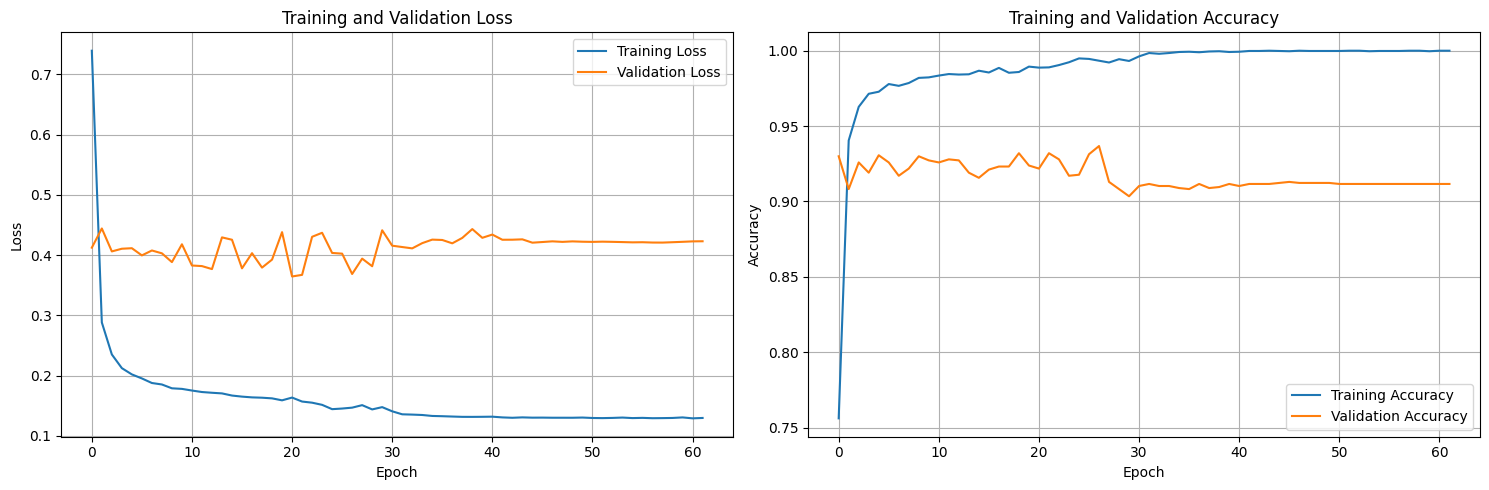

In [17]:
# 학습 곡선 시각화
train_loss = history.history['loss']
val_loss = history.history['val_loss']
train_accuracy = history.history['accuracy']
val_accuracy = history.history['val_accuracy']

plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
plt.plot(train_loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(train_accuracy, label='Training Accuracy')
plt.plot(val_accuracy, label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

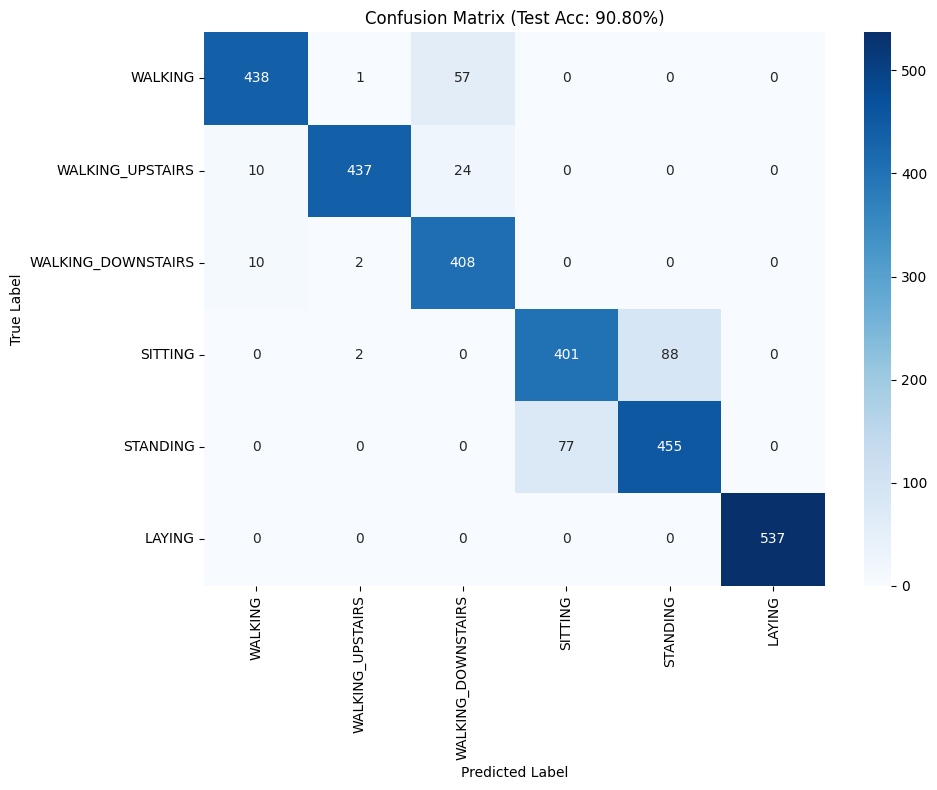

In [18]:
# 혼동 행렬
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=LABELS,
    yticklabels=LABELS
)
plt.title(f'Confusion Matrix (Test Acc: {test_acc * 100:.2f}%)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

# Model 2: Conv1D + Mamba-like

Model 2는 비교 실험을 위해 Conv1D로 짧은 구간의 local pattern을 먼저 추출한 뒤, 그 결과를 Mamba-like block에 입력한다.


In [19]:
# Model 2 정의: Conv1D로 local feature를 추출한 뒤 Mamba-like block 적용
def build_conv1d_mambalike_model(input_shape, num_classes):
    inputs = Input(shape=input_shape)  # (128, 9)

    # 약한 노이즈 추가
    x = GaussianNoise(0.01)(inputs)

    # Conv1D local feature extraction
    # padding='same'을 사용하므로 time length는 128로 유지됨
    # Conv1D로 local pattern을 먼저 추출
    x = Conv1D(filters=64, kernel_size=5, padding='same', use_bias=False)(x)
    x = BatchNormalization()(x)
    x = ReLU()(x)

    x = Conv1D(filters=128, kernel_size=3, padding='same', use_bias=False)(x)
    x = BatchNormalization()(x)
    x = ReLU()(x)

    x = LayerNormalization()(x)

    #  Mamba-like block stack
    # Conv1D가 local pattern을 추출하고, Mamba-like block이 시간축 상태 누적을 학습
    x = MambaLikeBlock(d_model=128, expand=2, dropout=0.1)(x)
    x = MambaLikeBlock(d_model=128, expand=2, dropout=0.1)(x)
    x = MambaLikeBlock(d_model=128, expand=2, dropout=0.1)(x)

    avg_pool = GlobalAveragePooling1D()(x)
    max_pool = GlobalMaxPooling1D()(x)
    x = Concatenate()([avg_pool, max_pool])

    x = Dense(128, activation='relu')(x)
    x = Dropout(0.4)(x)

    x = Dense(64, activation='relu')(x)
    x = Dropout(0.2)(x)

    outputs = Dense(num_classes, activation='softmax')(x)

    model = Model(inputs, outputs, name='Conv1D_MambaLike_Model')
    return model


In [20]:
# Model 2 생성 및 컴파일
input_shape = (X_train.shape[1], X_train.shape[2])   # (128, 9)
num_classes = 6

model2 = build_conv1d_mambalike_model(input_shape, num_classes)

model2.compile(
    optimizer=Adam(learning_rate=3e-4),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.02),
    metrics=['accuracy']
)

model2.summary()


Model: "Conv1D_MambaLike_Model"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 128, 9)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gaussian_noise_1    │ (None, 128, 9)    │          0 │ input_layer_1[0]… │
│ (GaussianNoise)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 128, 64)   │      2,880 │ gaussian_noise_1… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 128, 64)   │        256 │ conv1d[0][0]      │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu (ReLU)        │ (None, 128, 64)   │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 128, 128)  │     24,576 │ re_lu[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128)  │        512 │ conv1d_1[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_1 (ReLU)      │ (None, 128, 128)  │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 128, 128)  │        256 │ re_lu_1[0][0]     │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mamba_like_block_3  │ (None, 128, 128)  │    198,272 │ layer_normalizat… │
│ (MambaLikeBlock)    │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mamba_like_block_4  │ (None, 128, 128)  │    198,272 │ mamba_like_block… │
│ (MambaLikeBlock)    │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mamba_like_block_5  │ (None, 128, 128)  │    198,272 │ mamba_like_block… │
│ (MambaLikeBlock)    │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 128)       │          0 │ mamba_like_block… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 128)       │          0 │ mamba_like_block… │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 256)       │          0 │ global_average_p… │
│ (Concatenate)       │                   │            │ global_max_pooli… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_49 (Dense)    │ (None, 128)       │     32,896 │ concatenate_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_11          │ (None, 128)       │          0 │ dense_49[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_50 (Dense)    │ (None, 64)        │      8,256 │ dropout_11[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_12          │ (None, 64)        │          0 │ dense_50[0][0]  

 Total params: 664,838 (2.54 MB)

 Trainable params: 664,454 (2.53 MB)

 Non-trainable params: 384 (1.50 KB)

In [21]:
# Model 2 Callback 설정
callbacks2 = [
    ModelCheckpoint(
        "UCI_HAR_Conv1D_MambaLike_best.keras",
        monitor="val_accuracy",
        mode="max",
        save_best_only=True,
        verbose=1
    ),

    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.2,
        patience=10,
        min_lr=1e-6,
        verbose=1
    ),

    EarlyStopping(
        monitor="val_accuracy",
        mode="max",
        patience=35,
        restore_best_weights=True,
        verbose=1
    )
]


In [22]:
# Model 2 학습
history2 = model2.fit(
    X_train, y_train_onehot,
    epochs=200,
    batch_size=64,
    validation_split=0.2,
    callbacks=callbacks2,
    shuffle=True,
    verbose=1
)


Epoch 1/200
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step - accuracy: 0.5338 - loss: 1.4994
Epoch 1: val_accuracy improved from None to 0.92114, saving model to UCI_HAR_Conv1D_MambaLike_best.keras

Epoch 1: finished saving model to UCI_HAR_Conv1D_MambaLike_best.keras
92/92 ━━━━━━━━━━━━━━━━━━━━ 34s 170ms/step - accuracy: 0.6955 - loss: 0.9359 - val_accuracy: 0.9211 - val_loss: 0.4901 - learning_rate: 3.0000e-04
Epoch 2/200
91/92 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.8900 - loss: 0.4319
Epoch 2: val_accuracy did not improve from 0.92114
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.9109 - loss: 0.3719 - val_accuracy: 0.9184 - val_loss: 0.3878 - learning_rate: 3.0000e-04
Epoch 3/200
91/92 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.9385 - loss: 0.2819
Epoch 3: val_accuracy did not improve from 0.92114
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.9418 - loss: 0.2777 - val_accuracy: 0.9116 - val_loss: 0.4039 - learning_rate: 3.0000e-04
Epoch 4/200
91/92 ━━━━━━━━━━━

In [23]:
# 저장된 Model 2 로드
model2 = tf.keras.models.load_model(
    "UCI_HAR_Conv1D_MambaLike_best.keras",
    custom_objects={"MambaLikeBlock": MambaLikeBlock}
)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:424: UserWarning: `build()` was called on layer 'mamba_like_block_3', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:424: UserWarning: `build()` was called on layer 'mamba_like_block_4', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:424: UserWarning: `build()` was called on layer 'mamba_like_block_5', howeve

In [24]:
# Model 2 학습 및 테스트 성능 평가
train_loss2, train_acc2 = model2.evaluate(X_train, y_train_onehot, verbose=0)
test_loss2, test_acc2 = model2.evaluate(X_test, y_test_onehot, verbose=0)

print(f"Model 2 Training accuracy: {train_acc2 * 100:.2f}%")
print(f"Model 2 Training loss: {train_loss2:.4f}")
print(f"Model 2 Test accuracy: {test_acc2 * 100:.2f}%")
print(f"Model 2 Test loss: {test_loss2:.4f}")


Model 2 Training accuracy: 98.72%
Model 2 Training loss: 0.1625
Model 2 Test accuracy: 94.98%
Model 2 Test loss: 0.2775


In [25]:
# Model 2 예측 및 분류 리포트
y_pred_proba2 = model2.predict(X_test, verbose=0)
y_pred2 = np.argmax(y_pred_proba2, axis=1)

print("\nModel 2 Classification Report:")
print(classification_report(y_test, y_pred2, digits=4))



Model 2 Classification Report:
              precision    recall  f1-score   support

           0     0.9838    0.9778    0.9808       496
           1     0.9595    0.9554    0.9574       471
           2     0.9672    0.9833    0.9752       420
           3     0.9482    0.8208    0.8799       491
           4     0.8646    0.9605    0.9101       532
           5     0.9908    1.0000    0.9954       537

    accuracy                         0.9498      2947
   macro avg     0.9524    0.9496    0.9498      2947
weighted avg     0.9514    0.9498    0.9493      2947



In [26]:
# Model 1과 Model 2 성능 비교
print("Model 1: Mamba-like only")
print(f"Test accuracy: {test_acc * 100:.2f}%")
print(f"Test loss: {test_loss:.4f}")

print("\nModel 2: Conv1D + Mamba-like")
print(f"Test accuracy: {test_acc2 * 100:.2f}%")
print(f"Test loss: {test_loss2:.4f}")


Model 1: Mamba-like only
Test accuracy: 90.80%
Test loss: 0.4423

Model 2: Conv1D + Mamba-like
Test accuracy: 94.98%
Test loss: 0.2775
